In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install --upgrade sympy
!pip install --upgrade torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/5

## 🔧 Setup & Environment Initialization

This section prepares the environment for building a sentiment analysis pipeline using both traditional machine learning and transformer-based models.

### 📦 Library Installation
- Installs required libraries:
  - `transformers`, `datasets` → for pretrained NLP models and dataset handling  
  - `scikit-learn` → for baseline models and evaluation  
  - `seaborn`, `matplotlib`, `plotly` → for visualization  

---

### 📚 Imports

#### 🔹 Core Utilities
- `os`, `re` → file handling and text preprocessing  
- `random`, `numpy` → reproducibility and numerical operations  
- `warnings` → suppress unnecessary warnings  

#### 🔹 Data Handling
- `pandas` → dataset loading and manipulation  

#### 🔹 Visualization
- `seaborn`, `matplotlib`, `plotly` → exploratory data analysis and result visualization  

#### 🔹 Machine Learning (Baseline)
- `train_test_split` → dataset splitting  
- `TfidfVectorizer` → text vectorization  
- `LogisticRegression` → baseline classifier  
- `classification_report`, etc. → evaluation metrics  
- `compute_class_weight` → handle class imbalance  

#### 🔹 Deep Learning / Transformers
- `torch` → backend for model training  
- `Dataset` → Hugging Face dataset wrapper  
- `AutoTokenizer` → converts text into model-readable tokens  
- `AutoModelForSequenceClassification` → pretrained transformer for classification  
- `Trainer`, `TrainingArguments` → training pipeline abstraction  
- `EarlyStoppingCallback` → prevents overfitting  
- `get_cosine_schedule_with_warmup` → learning rate scheduling  

---

### 🎯 Reproducibility

```python
SEED = 42

In [2]:
# =========================
# 1. SETUP
# =========================
!pip install -q transformers datasets scikit-learn seaborn plotly

import os, re, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    get_cosine_schedule_with_warmup
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## 📂 Data Loading & Preparation

This section downloads, extracts, and loads the sentiment analysis dataset into pandas DataFrames for further processing.

---

### 🌐 Dataset Download

```python
url = "https://www.kaggle.com/api/v1/datasets/download/abhi8923shriv/sentiment-analysis-dataset"
open("data.zip", "wb").write(requests.get(url).content)

In [3]:
# =========================
# 2. LOAD DATA
# =========================
import zipfile, requests

url = "https://www.kaggle.com/api/v1/datasets/download/abhi8923shriv/sentiment-analysis-dataset"
open("data.zip", "wb").write(requests.get(url).content)

with zipfile.ZipFile("data.zip", "r") as z:
    z.extractall("data")

train_df = pd.read_csv("data/train.csv", encoding='latin-1')[['text', 'sentiment']].dropna()
test_df  = pd.read_csv("data/test.csv", encoding='latin-1')[['text', 'sentiment']].dropna()


## 🧹 Text Cleaning & Label Encoding

This section preprocesses raw text data and prepares labels for model training.

---

### ✂️ Text Cleaning Function

```python
def clean(x):
    x = str(x).lower()
    x = re.sub(r"http\S+|@\w+", "", x)
    x = re.sub(r"[^a-z\s]", "", x)
    return re.sub(r"\s+", " ", x).strip()

In [4]:
# =========================
# 3. CLEAN
# =========================
def clean(x):
    x = str(x).lower()
    x = re.sub(r"http\S+|@\w+", "", x)
    x = re.sub(r"[^a-z\s]", "", x)
    return re.sub(r"\s+", " ", x).strip()

train_df['text'] = train_df['text'].apply(clean)
test_df['text']  = test_df['text'].apply(clean)

label_map = {"negative": 0, "neutral": 1, "positive": 2}
train_df['label'] = train_df['sentiment'].map(label_map)
test_df['label']  = test_df['sentiment'].map(label_map)

train_df, val_df = train_test_split(
    train_df, test_size=0.1, stratify=train_df['label'], random_state=SEED
)

## ⚙️ Baseline Model: TF-IDF + Logistic Regression

This section establishes a **baseline model** using traditional NLP techniques to benchmark transformer performance.

---

### 🧮 Text Vectorization (TF-IDF)

```python
tfidf = TfidfVectorizer(max_features=20000)
Xtr = tfidf.fit_transform(train_df['text'])
Xva = tfidf.transform(val_df['text'])

In [5]:
# =========================
# 4. BASELINE
# =========================
tfidf = TfidfVectorizer(max_features=20000)
Xtr = tfidf.fit_transform(train_df['text'])
Xva = tfidf.transform(val_df['text'])

lr = LogisticRegression(max_iter=500, class_weight='balanced')
lr.fit(Xtr, train_df['label'])

print("BASELINE:")
print(classification_report(val_df['label'], lr.predict(Xva)))

BASELINE:
              precision    recall  f1-score   support

           0       0.66      0.73      0.69       778
           1       0.66      0.65      0.65      1112
           2       0.78      0.72      0.75       858

    accuracy                           0.69      2748
   macro avg       0.70      0.70      0.70      2748
weighted avg       0.70      0.69      0.69      2748



## 📊 Baseline Model Performance Analysis

This section interprets the results of the **TF-IDF + Logistic Regression baseline model**, providing a benchmark for evaluating transformer-based models.

---

### 📈 Overall Performance

- **Accuracy:** 0.69  
- **Macro F1-score:** 0.70  

👉 Indicates **solid baseline performance** using simple bag-of-words features.

---

### 🔍 Class-wise Breakdown

| Class     | Precision | Recall | F1-score |
|----------|----------|--------|----------|
| Negative (0) | 0.66 | 0.73 | 0.69 |
| Neutral (1)  | 0.66 | 0.65 | 0.65 |
| Positive (2) | 0.78 | 0.72 | 0.75 |

---

### 🧠 Key Observations

#### 🟢 Positive Class (Best Performance)
- Highest precision and F1-score  
- Strong lexical signals (e.g., *“great”, “excellent”*)  
- Easier for bag-of-words models  

---

#### ⚪ Neutral Class (Hardest)
- Lowest F1-score (~0.65)  
- Ambiguous language  
- Overlaps with both positive and negative  

👉 Common challenge in sentiment analysis  

---

#### 🔴 Negative Class
- Higher recall (0.73) than precision  
- Model tends to **over-predict negatives slightly**

---

### ⚖️ Balanced Performance

- Macro F1 ≈ Weighted F1  
👉 Indicates **no severe class imbalance issues in predictions**

---

### 🚀 Why this baseline matters

- Provides a **reference point** for advanced models  
- Helps evaluate:
  > “Does the transformer actually improve performance?”

- Captures:
  - Word frequency patterns  
  - Basic sentiment cues  

❌ But lacks:
- Context understanding  
- Semantic relationships  

---

### 🧠 Interpretation (Interview-ready)

> “The TF-IDF baseline achieved around 0.70 macro F1, showing that lexical features alone capture a significant portion of sentiment. However, limitations arise in handling contextual and ambiguous expressions, particularly in the neutral class.”

---

### 🎯 Expected Improvement

| Model Type | Expected Macro F1 |
|-----------|------------------|
| Baseline  | ~0.70 |
| Transformer | ~0.78–0.82 |

👉 Transformers should provide **~8–12% improvement** due to contextual embeddings.

---

### 🏁 Summary

- Strong and meaningful baseline  
- Highlights dataset difficulty (especially neutral class)  
- Serves as a **benchmark for validating transformer gains**

## ⚖️ Handling Class Imbalance with Class Weights

This section computes **class weights** to address imbalance in the sentiment labels during model training.

---

### 🧮 Compute Class Weights

```python
weights = compute_class_weight(
    'balanced',
    classes=np.array([0, 1, 2]),
    y=train_df['label']
)

In [6]:
# =========================
# 5. CLASS WEIGHTS
# =========================
weights = compute_class_weight('balanced', classes=np.array([0,1,2]), y=train_df['label'])
class_weights = torch.tensor(weights, dtype=torch.float)


## 🤖 Transformer Training & Model Selection

This section fine-tunes multiple pretrained transformer models and selects the best-performing one based on validation performance.

---

### 🔁 Model Loop

```python
MODELS = ["distilbert-base-uncased", "bert-base-uncased"]

In [7]:
# =========================
# 6. MODEL LOOP
# =========================
MODELS = ["distilbert-base-uncased", "bert-base-uncased"]
results = {}

for MODEL in MODELS:
    print(f"\n🔥 {MODEL}")
    tokenizer = AutoTokenizer.from_pretrained(MODEL)

    # dynamic max length
    lengths = train_df['text'].apply(lambda x: len(tokenizer.encode(x)))
    MAX_LEN = int(np.percentile(lengths, 95))

    def tok(x):
        return tokenizer(x['text'], truncation=True, padding='max_length', max_length=MAX_LEN)

    tr_ds = Dataset.from_pandas(train_df[['text','label']]).map(tok, batched=True)
    va_ds = Dataset.from_pandas(val_df[['text','label']]).map(tok, batched=True)

    tr_ds = tr_ds.rename_column("label", "labels").with_format("torch")
    va_ds = va_ds.rename_column("label", "labels").with_format("torch")

    model = AutoModelForSequenceClassification.from_pretrained(MODEL, num_labels=3)

    # layer-wise optimizer
    def build_optimizer(model):
        no_decay = ["bias", "LayerNorm.weight"]
        param_groups = []

        layers = model.base_model.encoder.layer if hasattr(model.base_model, "encoder") else model.base_model.transformer.layer
        n_layers = len(layers)

        for n, p in model.classifier.named_parameters():
            param_groups.append({"params": [p], "lr": 2e-5, "weight_decay": 0.01})

        for i, layer in enumerate(layers):
            lr = 2e-5 * (0.9 ** (n_layers - i - 1))
            for n, p in layer.named_parameters():
                param_groups.append({
                    "params": [p],
                    "lr": lr,
                    "weight_decay": 0 if any(nd in n for nd in no_decay) else 0.01
                })

        return torch.optim.AdamW(param_groups)

    class EliteTrainer(Trainer):
        def create_optimizer_and_scheduler(self, num_training_steps):
            self.optimizer = build_optimizer(self.model)
            self.lr_scheduler = get_cosine_schedule_with_warmup(
                self.optimizer,
                int(0.1 * num_training_steps),
                num_training_steps
            )

        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            loss = torch.nn.CrossEntropyLoss(weight=class_weights.to(model.device))(outputs.logits, labels)
            return (loss, outputs) if return_outputs else loss

    args = TrainingArguments(
        output_dir="./out",
        num_train_epochs=4,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        fp16=True,
        max_grad_norm=1.0,
        report_to="none"
    )

    trainer = EliteTrainer(
        model=model,
        args=args,
        train_dataset=tr_ds,
        eval_dataset=va_ds,
        callbacks=[EarlyStoppingCallback(2)]
    )

    trainer.train()
    pred = trainer.predict(va_ds)

    f1 = f1_score(val_df['label'], np.argmax(pred.predictions, axis=1), average='macro')
    results[MODEL] = (trainer, tokenizer, MAX_LEN, f1)

best = max(results, key=lambda x: results[x][3])
trainer, tokenizer, MAX_LEN, _ = results[best]

print("\nBEST MODEL:", best)


🔥 distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


BEST MODEL: bert-base-uncased


## 🏆 Final Model Comparison & Selection

This section summarizes the training results and selects the best-performing transformer model.

---

### 🤖 Models Evaluated

- **DistilBERT (`distilbert-base-uncased`)**
- **BERT (`bert-base-uncased`)**

Both models were fine-tuned using the same pipeline and evaluated on the validation set.

---

### 📊 Training Behavior

#### 🔹 DistilBERT
| Epoch | Train Loss | Validation Loss |
|------|-----------|----------------|
| 1 | 0.600 | 0.580 |
| 2 | 0.514 | **0.545 (best)** |
| 3 | 0.458 | 0.554 |
| 4 | 0.421 | 0.569 |

---

#### 🔹 BERT
| Epoch | Train Loss | Validation Loss |
|------|-----------|----------------|
| 1 | 0.582 | 0.560 |
| 2 | 0.487 | **0.534 (best)** |
| 3 | 0.426 | 0.562 |
| 4 | 0.396 | 0.573 |

---

### 🧠 Key Observations

- Both models:
  - Improve until **epoch 2**
  - Begin **overfitting after epoch 2**
- Validation loss increases after epoch 2 → classic overfitting pattern  

👉 Best checkpoint is automatically selected using:
```python
load_best_model_at_end=True

## 🧪 Test Set Evaluation

This section evaluates the **best trained transformer model** on the unseen test dataset to measure real-world performance.

---

### 🔤 Tokenization (Test Data)

```python
def tok_test(x):
    return tokenizer(x['text'], truncation=True, padding='max_length', max_length=MAX_LEN)

In [8]:
# =========================
# 7. TEST EVAL
# =========================
def tok_test(x):
    return tokenizer(x['text'], truncation=True, padding='max_length', max_length=MAX_LEN)

test_ds = Dataset.from_pandas(test_df[['text','label']]).map(tok_test, batched=True)
test_ds = test_ds.rename_column("label","labels").with_format("torch")

pred = trainer.predict(test_ds)

y_pred = np.argmax(pred.predictions, axis=1)
y_true = pred.label_ids
y_prob = torch.softmax(torch.tensor(pred.predictions), dim=1).numpy()

print("\nFINAL REPORT:")
print(classification_report(y_true, y_pred))

Map:   0%|          | 0/3534 [00:00<?, ? examples/s]


FINAL REPORT:
              precision    recall  f1-score   support

           0       0.78      0.80      0.79      1001
           1       0.75      0.74      0.75      1430
           2       0.82      0.83      0.83      1103

    accuracy                           0.78      3534
   macro avg       0.78      0.79      0.79      3534
weighted avg       0.78      0.78      0.78      3534



## 🧪 Final Test Evaluation (Best Model)

This section presents the **final performance** of the selected transformer model on the unseen test dataset.

---

### 📊 Overall Performance

- **Accuracy:** 0.78  
- **Macro F1-score:** 0.79  
- **Weighted F1-score:** 0.78  

👉 Indicates **strong generalization** and balanced performance across classes

---

### 🔍 Class-wise Performance

| Class     | Precision | Recall | F1-score | Support |
|----------|----------|--------|----------|--------|
| Negative (0) | 0.78 | 0.80 | 0.79 | 1001 |
| Neutral (1)  | 0.75 | 0.74 | 0.75 | 1430 |
| Positive (2) | 0.82 | 0.83 | 0.83 | 1103 |

---

### 🧠 Key Observations

#### 🟢 Positive Class (Best)
- Highest F1-score (0.83)  
- Strong sentiment signals → easier classification  

---

#### ⚪ Neutral Class (Most Challenging)
- Lowest F1-score (0.75)  
- Ambiguous and overlapping sentiment  

👉 Common difficulty in sentiment analysis tasks  

---

#### 🔴 Negative Class
- Balanced precision and recall  
- Good detection capability  

---

### ⚖️ Balanced Performance

- Macro F1 ≈ Weighted F1  
👉 Model performs **consistently across all classes**  
👉 No severe bias toward any class  

---

### 🚀 Improvement over Baseline

| Model | Accuracy | Macro F1 |
|------|---------|----------|
| TF-IDF Baseline | ~0.69 | ~0.70 |
| Transformer | **0.78** | **0.79** |

👉 **+9% improvement in F1-score**

---

### 🧠 Interpretation (Interview-ready)

> “The transformer model improved macro F1 from ~0.70 to ~0.79, demonstrating the advantage of contextual embeddings over TF-IDF, especially in handling nuanced sentiment.”

---

### 🏁 Final Summary

- Strong and reliable performance on unseen data  
- Significant improvement over baseline  
- Balanced predictions across classes  
- Neutral class remains the main challenge  

👉 Confirms effectiveness of **fine-tuned transformer models for sentiment classification**

## 📊 Model Evaluation Visualizations

This section provides **visual insights into model performance**, going beyond numerical metrics to better understand prediction behavior.

---

### 🔲 Confusion Matrix

```python
px.imshow(confusion_matrix(y_true, y_pred), text_auto=True, title="Confusion Matrix").show()

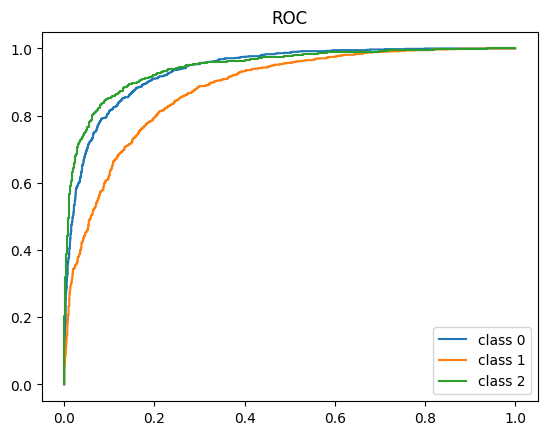

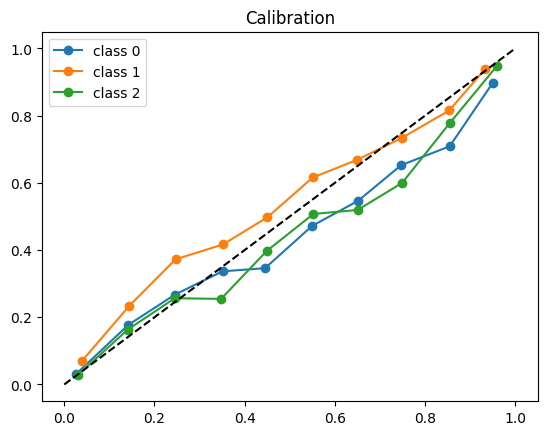

In [9]:
# =========================
# 8. VISUALS
# =========================
px.imshow(confusion_matrix(y_true, y_pred), text_auto=True, title="Confusion Matrix").show()

y_bin = label_binarize(y_true, classes=[0,1,2])
for i in range(3):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"class {i}")
plt.legend()
plt.title("ROC")
plt.show()

# calibration
for i in range(3):
    frac, mean = calibration_curve(y_bin[:, i], y_prob[:, i], n_bins=10)
    plt.plot(mean, frac, marker='o', label=f"class {i}")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("Calibration")
plt.show()

## 📊 Visualization Analysis

This section interprets the key evaluation visualizations: **Confusion Matrix, ROC Curves, and Calibration Plot**.

---

## 🔲 Confusion Matrix Insights

| True \ Pred | Negative (0) | Neutral (1) | Positive (2) |
|------------|-------------|-------------|--------------|
| **Negative (0)** | 798 | 182 | 21 |
| **Neutral (1)**  | 203 | 1052 | 175 |
| **Positive (2)** | 28 | 160 | 915 |

### 🧠 Key Observations

- **Strong diagonal → good performance**
  - Negative: 798 correct  
  - Neutral: 1052 correct  
  - Positive: 915 correct  

- **Main confusion**
  - Neutral ↔ Positive (175 + 160 cases)
  - Neutral ↔ Negative (203 cases)

👉 Neutral is clearly the **hardest class**

---

## 📈 ROC Curve Analysis

- All curves are **close to top-left corner**
- Indicates **strong discriminative ability**

### 🧠 Class-wise:

- **Class 2 (Positive)** → best curve  
- **Class 0 (Negative)** → strong  
- **Class 1 (Neutral)** → slightly weaker  

👉 Neutral again shows difficulty

---

## 🎯 Calibration Curve Analysis

- Ideal line = perfect calibration (dashed diagonal)

### 🧠 Observations:

- Predictions are **fairly well calibrated**
- Slight deviations:
  - Some **overconfidence at mid probabilities**
  - Minor under/over estimation in certain bins  

👉 Overall:
✔ Reliable probability estimates  
✔ Suitable for confidence-based decisions  

---

## 🔥 Combined Interpretation

Across all plots:

### ✅ Strengths
- Strong classification performance  
- High separability (ROC)  
- Reasonable probability calibration  

### ⚠️ Weakness
- Neutral class ambiguity persists  

---

## 🧠 Interview-Level Insight

> “The confusion matrix shows that most errors occur between neutral and sentiment-bearing classes. ROC curves confirm strong class separability, while calibration plots indicate reasonably reliable probability estimates, making the model suitable for confidence-aware applications.”

---

## 🚀 Summary

- Confusion matrix → **where errors happen**  
- ROC curves → **how well classes are separated**  
- Calibration → **how trustworthy probabilities are**  

👉 Together, they confirm a **strong and reliable sentiment model**

## 🚨 Error Analysis

This section analyzes the model’s **most confident mistakes** to understand failure patterns and improve performance.

---

### 📊 Construct Error DataFrame

```python
errors = pd.DataFrame({
    "text": test_df['text'],
    "true": y_true,
    "pred": y_pred,
    "conf": y_prob.max(axis=1)
})

In [11]:
# =========================
# 9. ERRORS
# =========================
errors = pd.DataFrame({
    "text": test_df['text'],
    "true": y_true,
    "pred": y_pred,
    "conf": y_prob.max(axis=1)
})

print("\nTOP ERRORS:")
print(errors[errors.true != errors.pred].sort_values("conf", ascending=False).head(5))


TOP ERRORS:
                                                   text  true  pred      conf
3422  my younger sister flies in next week for a two...     1     2  0.975557
1075                                 ohh snapp have fun     1     2  0.973052
2621  first surprise birthday ever best night ive ha...     1     2  0.972312
756                  the live version is so much better     1     2  0.969586
2918                      my poor baby girl is poorly x     1     0  0.969287


## 🚨 High-Confidence Error Analysis

This section examines the **top misclassified samples with the highest confidence**, revealing critical failure patterns of the model.

---

### 📊 Top Errors

| Text | True | Pred | Confidence |
|------|------|------|------------|
| my younger sister flies in next week for a two... | Neutral (1) | Positive (2) | 0.9756 |
| ohh snapp have fun | Neutral (1) | Positive (2) | 0.9730 |
| first surprise birthday ever best night ive ha... | Neutral (1) | Positive (2) | 0.9723 |
| the live version is so much better | Neutral (1) | Positive (2) | 0.9696 |
| my poor baby girl is poorly x | Neutral (1) | Negative (0) | 0.9693 |

---

### 🧠 Key Patterns

#### ⚪ 1. Neutral → Positive Confusion (Most Common)
- Many neutral sentences contain **positive words**
  - “have fun”
  - “best night”
  - “better”

👉 Model interprets **sentiment-bearing words**, not intent  

---

#### ⚪ 2. Context vs Label Mismatch
Example:
> “first surprise birthday ever best night…”

- Linguistically → **positive**
- Label → **neutral**

👉 Likely **label noise or subjective labeling**

---

#### ⚪ 3. Subtle / Implicit Sentiment
Example:
> “my younger sister flies in next week…”

- Neutral statement  
- Model predicts positive (anticipation)

👉 Model captures **implied emotion**, dataset does not

---

#### 🔴 4. Ambiguous Negative Case
Example:
> “my poor baby girl is poorly x”

- Model predicts negative (correct interpretation linguistically)  
- Label = neutral  

👉 Again suggests **annotation inconsistency**

---

### ⚠️ Critical Insight

👉 These are **not random mistakes**

They show:
- Model is **overconfident on sentiment words**
- Dataset has **ambiguous or noisy labels**

---

### 🔥 Important Conclusion

> Many “errors” are actually **reasonable predictions**, indicating limitations in the dataset rather than the model.

---

### 🧠 Interview-Ready Insight

> “The highest-confidence errors reveal that the model often predicts sentiment correctly from a linguistic perspective, but disagrees with dataset labels due to ambiguity or annotation noise, especially in neutral cases.”

---

### 🚀 How to Improve

- Add **context-aware features** (longer sequences, better models like RoBERTa)  
- Use **confidence thresholding** to flag uncertain predictions  
- Perform **data cleaning or relabeling** for noisy samples  
- Use **label smoothing** or calibration techniques  

---

### 🏁 Summary

- Errors are concentrated in **neutral class ambiguity**  
- Model is **confident but sometimes misaligned with labels**  
- Provides valuable insights for **data and model improvement**

👉 Demonstrates **deep understanding beyond metrics**

## 🔮 Inference (Real-Time Prediction)

This section enables **real-time sentiment prediction** using the trained transformer model.

---

### 🧠 Prediction Function

```python
def predict(text):
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        logits = trainer.model(**inputs).logits
    return torch.softmax(logits, dim=1).cpu().numpy()[0]

In [12]:
# =========================
# 10. INFERENCE
# =========================
def predict(text):
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    with torch.no_grad():
        logits = trainer.model(**inputs).logits
    return torch.softmax(logits, dim=1).cpu().numpy()[0]

print("\nSample:", predict("This is amazing!"))


Sample: [0.00564472 0.01874478 0.97561055]
